In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Access and Export Kaggle secrets to the environment

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

### Download Dataset

In [ ]:
!kaggle competitions download -c playground-series-s6e4
!unzip playground-series-s6e4

100% 32.5M/32.5M [00:02<00:00, 12.1MB/s]

Archive:  playground-series-s6e4.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


### Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### 1. Loading Dataset

In [4]:
train_path = 'dataset/train.csv'
test_path  = 'dataset/test.csv'
# sample_submission = 'sample_submission.csv'

In [5]:
# baca file csv
df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

In [6]:
# untuk melihat data teratas
df_train.head(n=5)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [7]:
# untuk melihat informasi kolom dataset
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  str    
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  str    
 12  Crop_Growth_Stage        630000 non-null  str    
 13  Season                   630000 non-null  str    
 14  Irrigation_Type

In [8]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  str    
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  str    
 12  Crop_Growth_Stage        270000 non-null  str    
 13  Season                   270000 non-null  str    
 14  Irrigation_Type

In [9]:
# untuk melihat statistika descriptive
df_train.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [10]:
# untuk melihat dimensi dataset (baris, kolom)
df_train.shape

(630000, 21)

In [11]:
# untuk melihat nilai yang hilang
missing_values = df_train.isnull().sum()
print(missing_values)

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64


In [12]:
# untuk melihat nilai NaN
nan_values = df_train.isna().sum()
print(nan_values)

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64


In [13]:
# untuk menghitung suatu nilai muncul berapa kali di dalam dataset
df_train['Irrigation_Need'].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


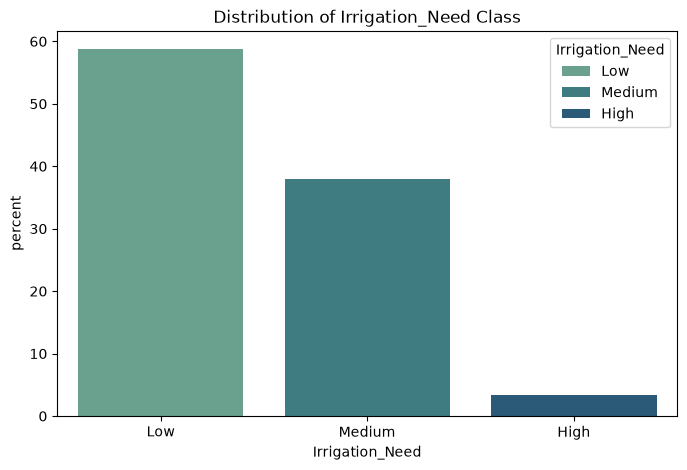

In [14]:
# untuk melihat distribusi data 'kebutuhan irigasi'
value_distribution = df_train['Irrigation_Need'].value_counts()
print(value_distribution)

plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='Irrigation_Need', hue='Irrigation_Need', palette='crest', stat='percent', legend='full')
plt.title('Distribution of Irrigation_Need Class')
plt.show()

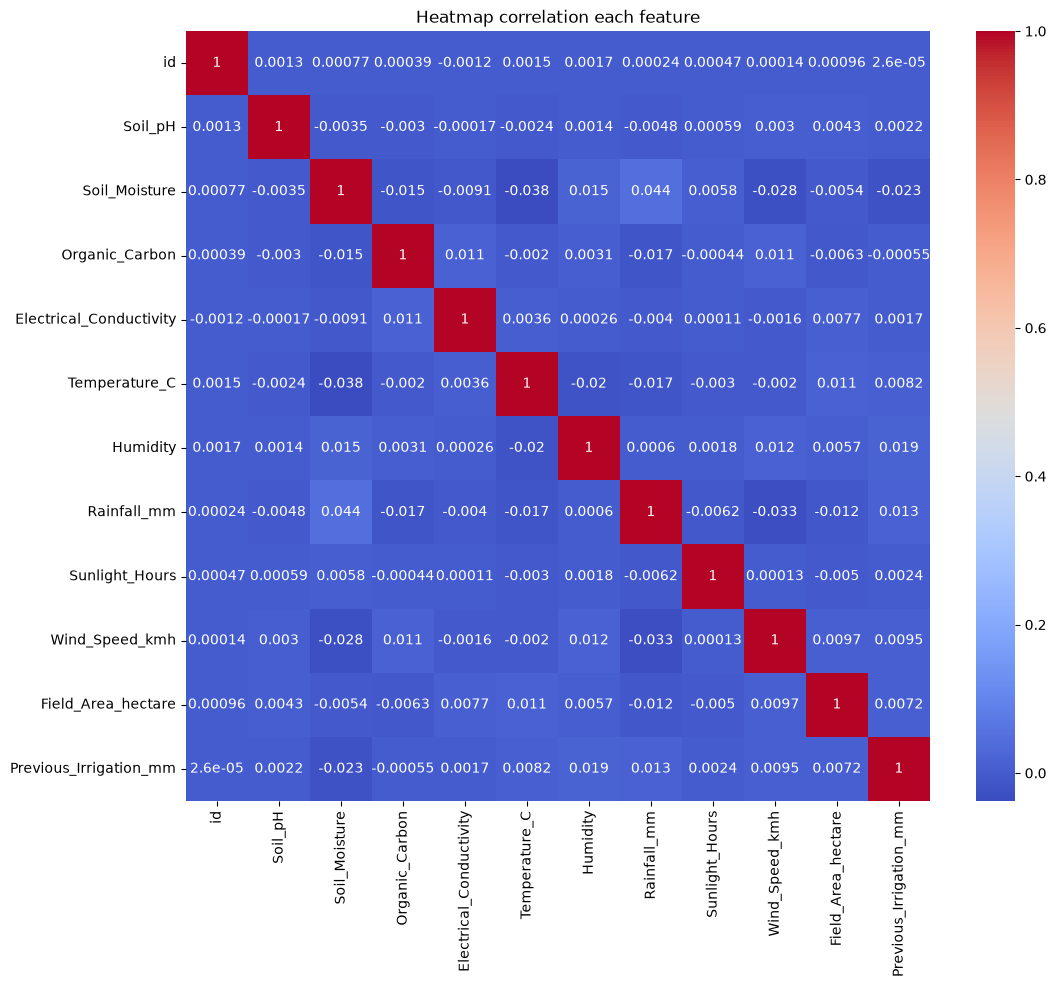

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_train.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap correlation each feature')
plt.show()

### 2. Preprocessing

In [16]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [17]:
X = df_train.drop(columns=['id', 'Irrigation_Need'])
y = df_train['Irrigation_Need']

X_test  = df_test.drop(columns=['id'])

#### 2.1 Feature Encoding

In [18]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y)

In [19]:
categorical_features = X.select_dtypes(include=['object']).columns
X_train_encoding = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=int)
X_test_encoding  = pd.get_dummies(X_test, columns=categorical_features, drop_first=True, dtype=int)

C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_12012\544889231.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


In [20]:
X_train_encoding, X_test_encoding = X_train_encoding.align(X_test_encoding, join='left', axis=1, fill_value=0)


In [21]:
X_train_encoding.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_Yes,Region_East,Region_North,Region_South,Region_West
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,...,0,0,1,0,0,0,1,0,0,0
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,...,1,0,0,0,1,1,0,0,1,0
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,...,0,1,0,1,0,1,0,1,0,0
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,...,0,0,0,0,1,1,0,0,1,0
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,...,0,0,0,0,1,0,0,0,1,0


In [22]:
X_test_encoding.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_Yes,Region_East,Region_North,Region_South,Region_West
0,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,13.59,...,0,0,0,0,1,1,0,0,0,1
1,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,6.12,...,0,0,0,1,0,1,0,0,1,0
2,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,3.11,...,0,1,0,1,0,1,1,0,0,0
3,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,2.27,...,0,0,0,0,0,0,0,1,0,0
4,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,12.39,...,0,0,0,0,0,1,0,0,0,0


In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_encoding, y_train_encoded,
    stratify=y_train_encoded,
    test_size=0.2,
    random_state=42
)

#### 2.2 Feature Scaling

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_encoding)

In [25]:
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_encoding.columns)
X_test_final  = pd.DataFrame(X_test_scaled, columns=X_test_encoding.columns)

In [26]:
X_train_final.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_Yes,Region_East,Region_North,Region_South,Region_West
0,-0.891583,0.858386,-1.265449,-0.298125,0.720137,0.241961,-1.120575,-0.642955,1.180950,1.449564,...,-0.572499,-0.586207,-0.566649,1.693271,-0.582449,1.005763,-0.500099,-0.470885,-0.522310,-0.512894
1,-0.371199,-1.788222,0.593317,1.675182,-0.713120,0.645344,1.488018,0.001929,-1.481543,-0.464046,...,1.746727,-0.586207,-0.566649,-0.590573,-0.582449,1.005763,-0.500099,-0.470885,-0.522310,1.949722
2,-0.772328,1.326045,0.429308,-1.253290,-1.456419,-1.196520,1.102430,-1.232850,0.015780,-1.597511,...,-0.572499,-0.586207,-0.566649,1.693271,-0.582449,1.005763,-0.500099,-0.470885,1.914572,-0.512894
3,-1.542062,1.579411,1.823382,-0.675992,-0.396551,-0.168526,-0.384006,-1.487804,-1.620379,-1.149342,...,-0.572499,-0.586207,-0.566649,1.693271,-0.582449,-0.994270,-0.500099,-0.470885,-0.522310,1.949722
4,-0.219421,-0.084259,0.511313,-0.182666,0.846532,0.480439,1.312258,0.476844,1.131742,-0.184237,...,-0.572499,-0.586207,-0.566649,-0.590573,-0.582449,1.005763,-0.500099,2.123663,-0.522310,-0.512894


In [27]:
X_test_final.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_Yes,Region_East,Region_North,Region_South,Region_West
0,-0.132690,-0.679516,-0.910097,1.118877,-1.063317,-1.589756,0.116253,-1.057881,-1.295256,1.440079,...,-0.572499,-0.586207,-0.566649,-0.590573,1.716889,1.005763,-0.500099,-0.470885,-0.522310,1.949722
1,-0.663915,-1.675276,0.702656,1.591211,-0.674853,0.837142,-1.445760,-0.148044,0.968302,-0.331256,...,-0.572499,-0.586207,-0.566649,1.693271,-0.582449,1.005763,-0.500099,-0.470885,1.914572,-0.512894
2,-0.284469,-0.657538,0.101291,-0.938400,-0.015045,-0.061972,-1.495933,0.956758,-1.360281,-1.045006,...,-0.572499,1.705883,-0.566649,1.693271,-0.582449,1.005763,1.999603,-0.470885,-0.522310,-0.512894
3,1.298364,0.992700,-0.254062,-1.253290,1.709269,-1.294956,-0.409704,-0.412996,-1.495602,-1.244192,...,-0.572499,-0.586207,-0.566649,-0.590573,-0.582449,-0.994270,-0.500099,2.123663,-0.522310,-0.512894
4,-1.357759,1.324824,-1.046770,0.384135,1.632736,-0.461804,-0.228789,-1.702765,-0.818995,1.155527,...,-0.572499,-0.586207,-0.566649,-0.590573,-0.582449,1.005763,-0.500099,-0.470885,-0.522310,-0.512894


In [28]:
# raise Exception('Stop Here')

### 3. Modeling

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn import svm

In [30]:
X_train.shape

(504000, 35)

In [31]:
y_train.shape

(504000,)

In [32]:
X_train.shape[0] == y_train.shape[0]
X_val.shape[0] == y_val.shape[0]

True

In [33]:
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

def evaluate_model(model_name, y_true, y_pred):
    print(f"=== {model_name} ===")

    # 1. Balanced Accuracy
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

    # 2. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # 3. Confusion Matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
      cm,
      annot=True,
      fmt="d",
      cmap="Blues",
    )
    plt.xlabel("Predicted", fontsize=11)
    plt.ylabel("True", fontsize=11)
    plt.show()

    print("\n" + "="*40 + "\n")

##logistic regression(baseline)

In [34]:
lr_model = LogisticRegression(
  random_state=42,
  max_iter=300,
  class_weight="balanced"
)

=== Logistic Regression ===
Balanced Accuracy: 0.7005

Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.86      0.34      4202
           1       0.81      0.75      0.78     73983
           2       0.57      0.49      0.53     47815

    accuracy                           0.65    126000
   macro avg       0.53      0.70      0.55    126000
weighted avg       0.70      0.65      0.67    126000

Confusion Matrix:


c:\Users\LENOVO LOQ\OneDrive\Desktop\Rangkuman semester 4\ml\tubes\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


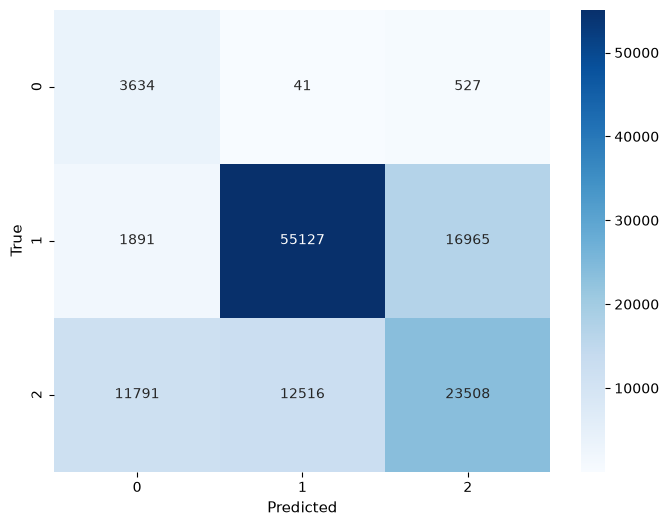

In [35]:
#baseline
lr_model.fit(X_train, y_train)
y_prediction_lr = lr_model.predict(X_val)
evaluate_model('Logistic Regression', y_val, y_prediction_lr)

##KNN(baseline)

c:\Users\LENOVO LOQ\OneDrive\Desktop\Rangkuman semester 4\ml\tubes\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


=== KNN ===
Balanced Accuracy: 0.6094

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.13      0.23      4202
           1       0.87      0.91      0.89     73983
           2       0.79      0.78      0.78     47815

    accuracy                           0.84    126000
   macro avg       0.83      0.61      0.64    126000
weighted avg       0.84      0.84      0.83    126000

Confusion Matrix:


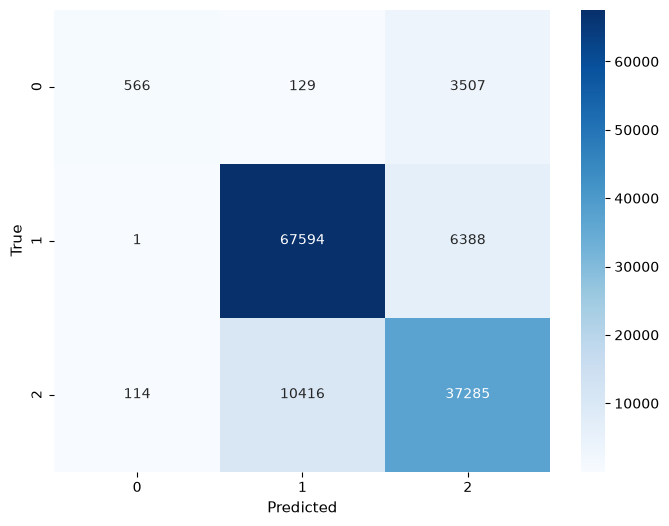

In [36]:
knn_model = KNeighborsClassifier(n_neighbors=11)
knn_model.fit(X_train_final, y_train)
y_prediction_knn = knn_model.predict(X_val_scaled)
evaluate_model('KNN', y_val, y_prediction_knn)

In [37]:
X_small = X_train_final.sample(n=30000, random_state=42)
y_small = y_train[X_small.index] # Correctly sample y_train_encoded using indices from X_small

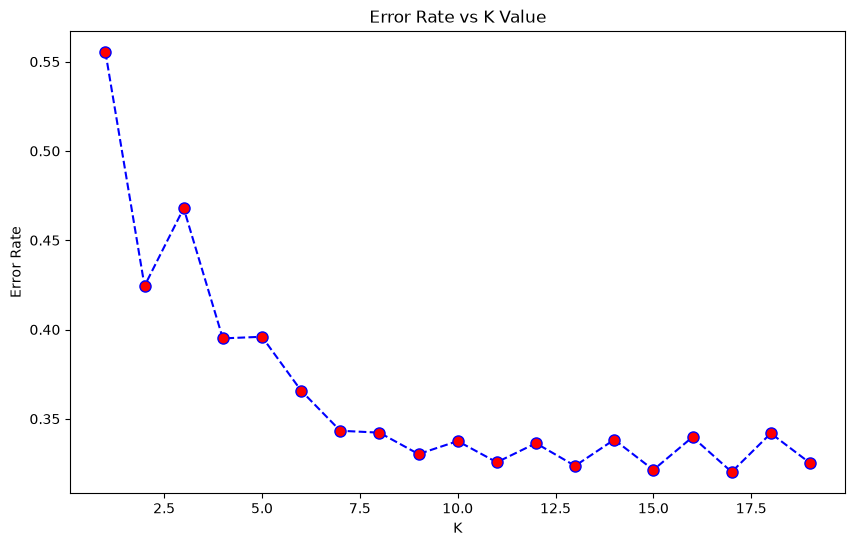

In [38]:
error_rate = []
for i in range(1, 20):
	knn = KNeighborsClassifier(n_neighbors=i)
	knn.fit(X_small, y_small)
	pred_i = knn.predict(X_val)
	error_rate.append(np.mean(pred_i != y_val))

plt.figure(figsize=(10,6))

plt.plot(
	range(1, 20),
	error_rate,
	color='blue',
	linestyle='dashed',
	marker='o',
	markerfacecolor='red',
	markersize=8
)
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

##Lightgbm(baseline)

In [39]:
lgbm_model=lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=3,
    num_leaves=31,
    learning_rate=0.05,
    class_weight='balanced',  # untuk data tidak seimbang
    random_state=42,
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2710
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 35
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

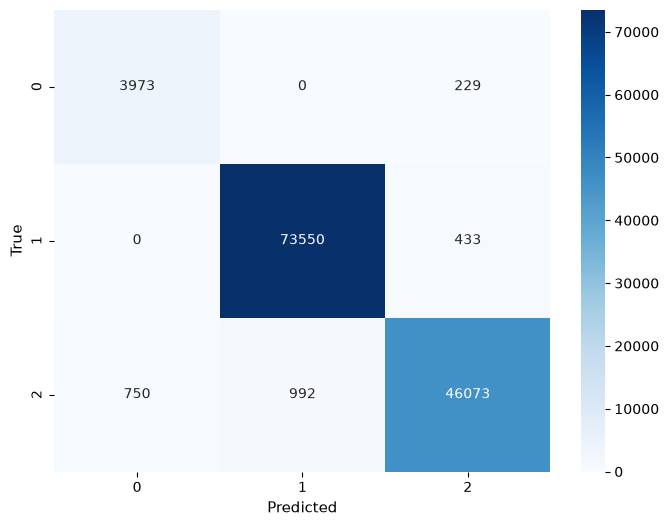

In [40]:
lgbm_model.fit(X_train, y_train)
y_prediction_lgbm = lgbm_model.predict(X_val)
evaluate_model('LightGBM', y_val, y_prediction_lgbm)

##Random forest

In [41]:
# model 1
rf_model = RandomForestClassifier(
  n_estimators=100,
  random_state=42,
  max_depth=10, # Reduced max_depth to address overfitting
  n_jobs=-1,
  class_weight="balanced"
)

=== Random Forest ===
Balanced Accuracy: 0.9669

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      4202
           1       0.99      0.99      0.99     73983
           2       0.98      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000

Confusion Matrix:


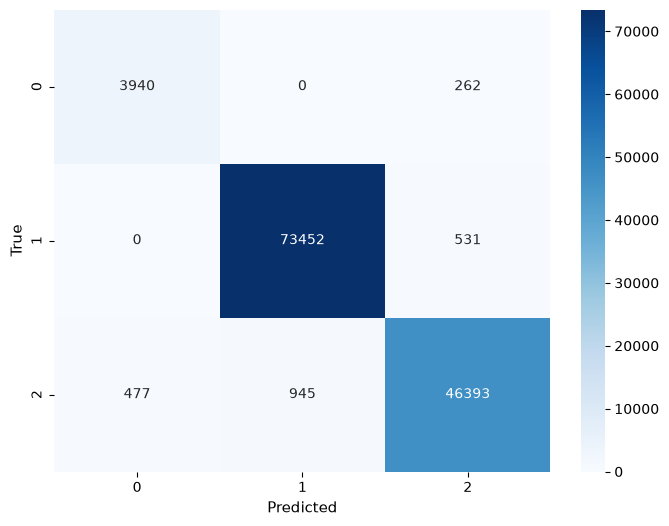

In [42]:
rf_model.fit(X_train, y_train)
y_prediction = rf_model.predict(X_val)
evaluate_model('Random Forest', y_val, y_prediction)

##xgboost

In [43]:
# model 2
xgb_model = xgb.XGBClassifier(
  n_estimators=100,
  random_state=42,
  max_depth=10, # Reduced max_depth to address overfitting
  n_jobs=-1,
  class_weight="balanced"
)

c:\Users\LENOVO LOQ\OneDrive\Desktop\Rangkuman semester 4\ml\tubes\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:43:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
Balanced Accuracy: 0.9634

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      4202
           1       0.99      0.99      0.99     73983
           2       0.98      0.98      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

Confusion Matrix:


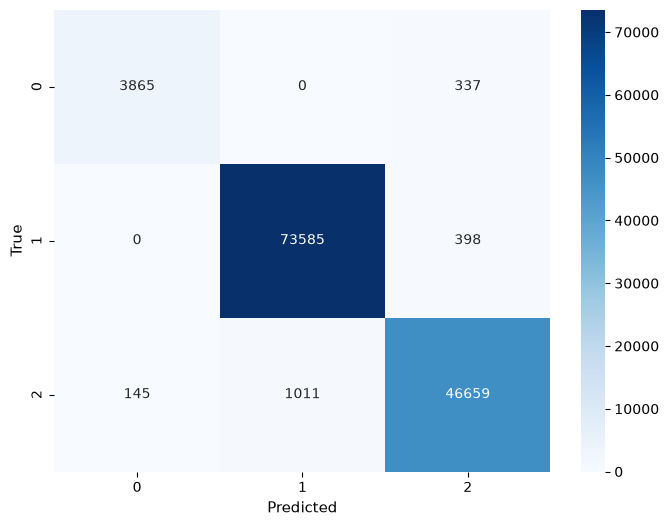

In [44]:
xgb_model.fit(X_train, y_train)
y_prediction_xgb = xgb_model.predict(X_val)
evaluate_model('XGBoost', y_val, y_prediction_xgb)

### 4. Check Overfitting & Underfitting

In [45]:
from sklearn.model_selection import learning_curve

In [46]:
X_small = X_train_encoding.sample(n=30000, random_state=42)
y_small = y_train_encoded[X_small.index] # Correctly sample y_train_encoded using indices from X_small

In [47]:
def plot_learning_curve(model, X, y, model_name):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=3, scoring='balanced_accuracy', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
    plt.plot(train_sizes, test_mean, label='Validation Score', marker='o')
    plt.title(f'Learning Curve: {model_name}')
    plt.xlabel('Training Set Size')
    plt.ylabel('Balanced Accuracy')
    plt.legend()
    plt.grid()
    plt.show()


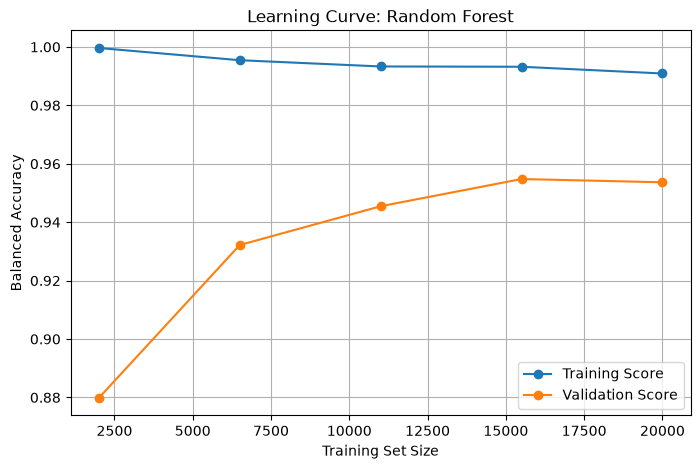

In [48]:
plot_learning_curve(rf_model, X_small, y_small, "Random Forest")

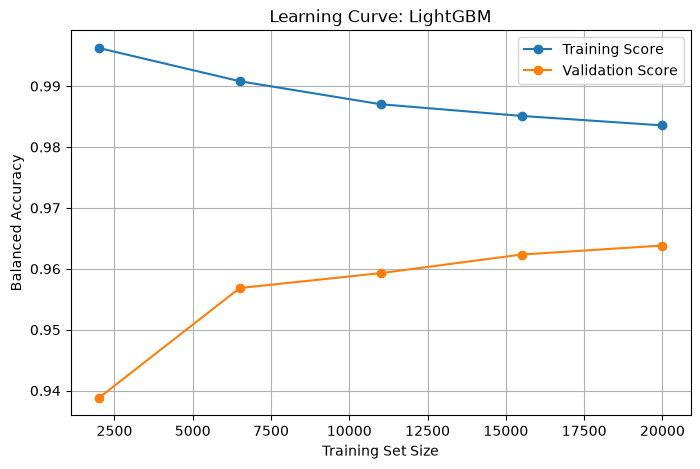

In [49]:
plot_learning_curve(lgbm_model, X_small, y_small, "LightGBM")

###**GUI**

In [ ]:
!pip install -q joblib

import os
import joblib

os.makedirs('artifacts', exist_ok=True)

# 1. Simpan model
joblib.dump(rf_model, 'artifacts/model_rf.pkl')
joblib.dump(lgbm_model, 'artifacts/model_lgbm.pkl')

# 2. Simpan label encoder target (Irrigation_Need)
joblib.dump(le, 'artifacts/label_encoder.pkl')

# 3. Simpan daftar kolom hasil one-hot encoding (urutan kolom WAJIB sama saat prediksi)
joblib.dump(list(X_train_encoding.columns), 'artifacts/encoded_columns.pkl')

# 4. Simpan info kolom asli: fitur numerik, fitur kategorikal, dan pilihan kategori tiap kolom
numeric_features = list(X.select_dtypes(include=['int64', 'float64']).columns)
categorical_features_list = list(categorical_features)

category_options = {col: sorted(X[col].dropna().unique().tolist()) for col in categorical_features_list}

# Simpan juga rentang nilai (min/max) tiap fitur numerik, untuk membuat slider di GUI
numeric_ranges = {
    col: (float(X[col].min()), float(X[col].max()), float(X[col].mean()))
    for col in numeric_features
}

joblib.dump(numeric_features, 'artifacts/numeric_features.pkl')
joblib.dump(categorical_features_list, 'artifacts/categorical_features.pkl')
joblib.dump(category_options, 'artifacts/category_options.pkl')
joblib.dump(numeric_ranges, 'artifacts/numeric_ranges.pkl')

# 5. Simpan data validasi (subset, biar ringan) untuk dashboard confusion matrix & classification report
import pandas as pd
val_sample = X_val.copy()
val_sample['__target__'] = y_val
val_sample.to_parquet('artifacts/validation_data.parquet', index=False)

print("Semua artefak berhasil disimpan di folder 'artifacts/' :")
for f in os.listdir('artifacts'):
    print(' -', f)


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Semua artefak berhasil disimpan di folder 'artifacts/' :
 - categorical_features.pkl
 - category_options.pkl
 - encoded_columns.pkl
 - label_encoder.pkl
 - model_lgbm.pkl
 - model_rf.pkl
 - numeric_features.pkl
 - numeric_ranges.pkl
 - validation_data.parquet


###streamlit


In [51]:
!pip install -q streamlit


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


buat

In [3]:
!pkill -f streamlit
!pkill -f localtunnel

'pkill' is not recognized as an internal or external command,
operable program or batch file.
'pkill' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
!streamlit run app.py --server.port 8501 &> /content/logs.txt & sleep 15 && npx localtunnel --port 8501

& was unexpected at this time.


In [2]:
!cat /content/logs.txt

'cat' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
!npx localtunnel --port 8501

'npx' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
!wget -q -O - ipv4.icanhazip.com

'wget' is not recognized as an internal or external command,
operable program or batch file.
